# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2977s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

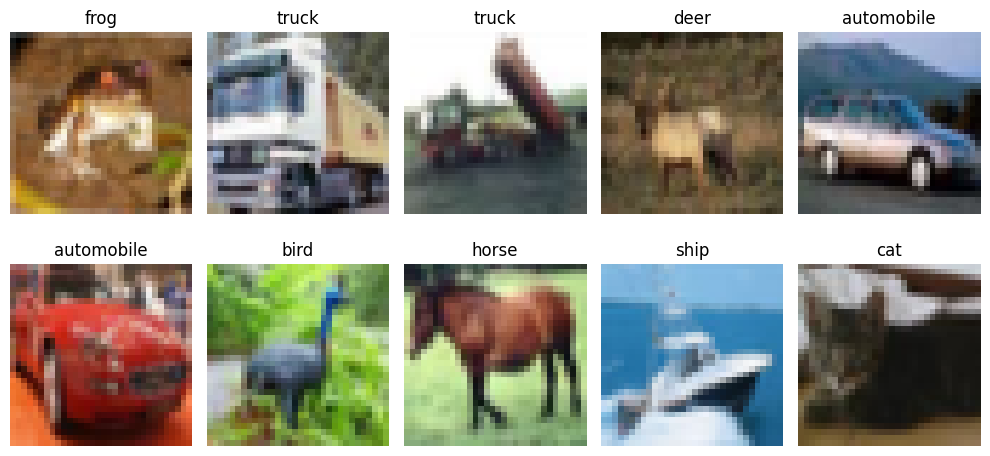

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.2629 - loss: 2.0064 - val_accuracy: 0.3104 - val_loss: 1.8790
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3050 - loss: 1.8851 - val_accuracy: 0.3646 - val_loss: 1.8108
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3268 - loss: 1.8326 - val_accuracy: 0.3748 - val_loss: 1.7684
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3433 - loss: 1.7968 - val_accuracy: 0.3746 - val_loss: 1.7469
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.3526 - loss: 1.7714 - val_accuracy: 0.3814 - val_loss: 1.7331
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3616 - loss: 1.7556 - val_accuracy: 0.3970 - val_loss: 1.7029
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3696 - loss: 1.7369 - val_accuracy: 0.4040 - val_loss: 1.6745
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3721 - loss: 1.7280 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4205 - loss: 1.6426
ANN Test Accuracy: 0.4205000102519989


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 124ms/step - accuracy: 0.4650 - loss: 1.4887 - val_accuracy: 0.5816 - val_loss: 1.2099
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.6097 - loss: 1.1206 - val_accuracy: 0.6024 - val_loss: 1.1154
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 122ms/step - accuracy: 0.6769 - loss: 0.9374 - val_accuracy: 0.6354 - val_loss: 1.0769
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.7165 - loss: 0.8167 - val_accuracy: 0.6672 - val_loss: 0.9881
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7490 - loss: 0.7235 - val_accuracy: 0.5968 - val_loss: 1.2612
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.7728 - loss: 0.6463 - val_accuracy: 0.7202 - val_loss: 0.8062
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - accuracy: 0.7942 - loss: 0.5806 - val_accuracy: 0.6610 - val_loss: 1.0899
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - accuracy: 0.8154 - loss

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6885 - loss: 0.9898
CNN Test Accuracy: 0.6884999871253967


## 📈 Compare Learning Curves

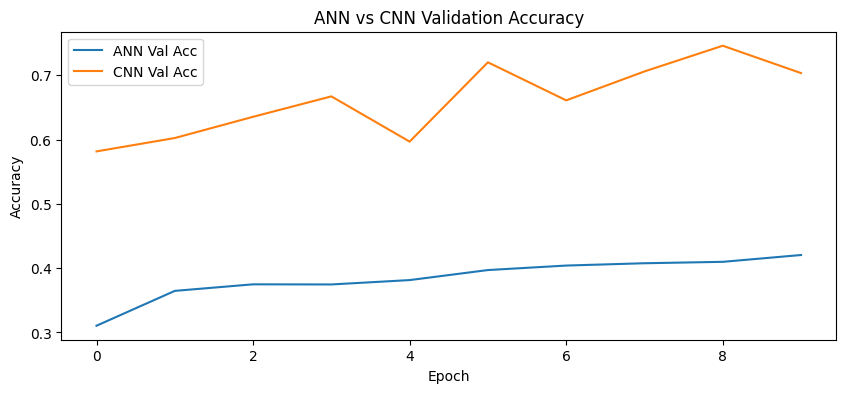

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4205
1,CNN,0.6885


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Task 1: Increase ANN layers, epochs, and add EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Create a new ANN model with more layers
ann_model_v2 = models.Sequential([
    Input(shape=(3072,)), # Changed to Input layer
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model V2 with more layers, 20 epochs, and EarlyStopping...")
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN Model V2 Test Accuracy:", ann_test_acc_v2)

Training ANN Model V2 with more layers, 20 epochs, and EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.3140 - loss: 1.9686 - val_accuracy: 0.3284 - val_loss: 1.8692
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.3814 - loss: 1.7207 - val_accuracy: 0.3832 - val_loss: 1.7190
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.4035 - loss: 1.6669 - val_accuracy: 0.3828 - val_loss: 1.7850
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.4120 - loss: 1.6432 - val_accuracy: 0.4296 - val_loss: 1.5937
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.4166 - loss: 1.6251 - val_accuracy: 0.4350 - val_loss: 1.6123
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4276 - loss: 1.5993 - val_accuracy: 0.4172 - val_loss: 1.6331
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.4351 - loss: 1.5830 - val_accuracy: 0.4540 - val_loss: 1.5194
Epoch 8/20
704/704

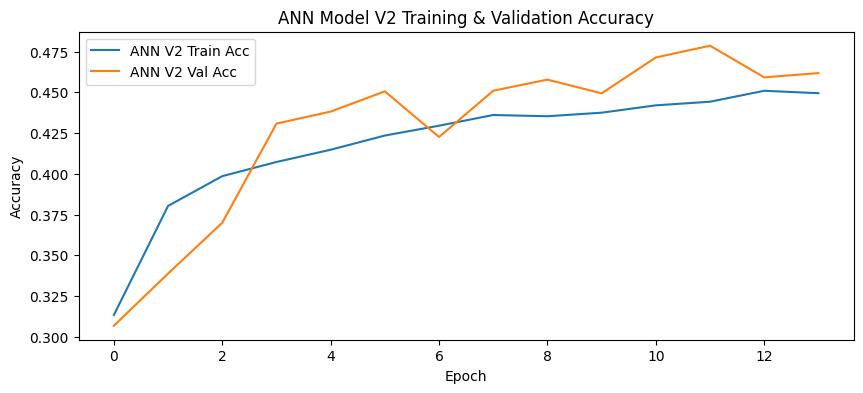

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(ann_history_v2.history['accuracy'], label='ANN V2 Train Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Model V2 Training & Validation Accuracy")
plt.legend()
plt.show()

## Task 2: Change CNN filters, increase epochs, and add EarlyStopping

In [ ]:
# Create a new CNN model with increased filters
cnn_model_v2 = models.Sequential([
    Input(shape=(32,32,3)), # Changed to Input layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model V2 with increased filters, 20 epochs, and EarlyStopping...")
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Model V2 Test Accuracy:", cnn_test_acc_v2)

Training CNN Model V2 with increased filters, 20 epochs, and EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 342ms/step - accuracy: 0.4966 - loss: 1.5821 - val_accuracy: 0.5610 - val_loss: 1.3363
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 254s 331ms/step - accuracy: 0.6517 - loss: 0.9980 - val_accuracy: 0.6004 - val_loss: 1.1142
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 329ms/step - accuracy: 0.7162 - loss: 0.8114 - val_accuracy: 0.6312 - val_loss: 1.1178
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 341ms/step - accuracy: 0.7602 - loss: 0.6823 - val_accuracy: 0.6844 - val_loss: 0.9177
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 238s 338ms/step - accuracy: 0.7950 - loss: 0.5821 - val_accuracy: 0.6868 - val_loss: 1.0495
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 242s 344ms/step - accuracy: 0.8291 - loss: 0.4883 - val_accuracy: 0.7096 - val_loss: 0.9458
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 338ms/step - accuracy: 0.8511 - loss: 0.4162 - val_accuracy: 0.6604 - val_loss: 1.156

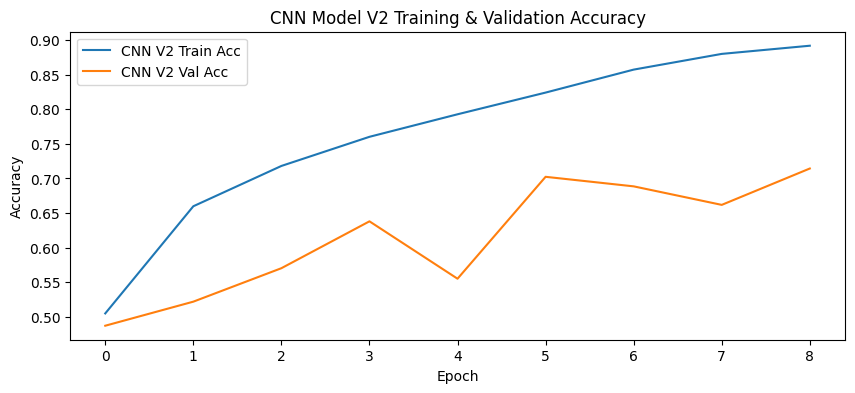

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(cnn_history_v2.history['accuracy'], label='CNN V2 Train Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Model V2 Training & Validation Accuracy")
plt.legend()
plt.show()

## Task 3: Evaluate Data Augmentation Training

In [ ]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6162 - loss: 1.0678
Augmented CNN Test Accuracy: 0.6161999702453613


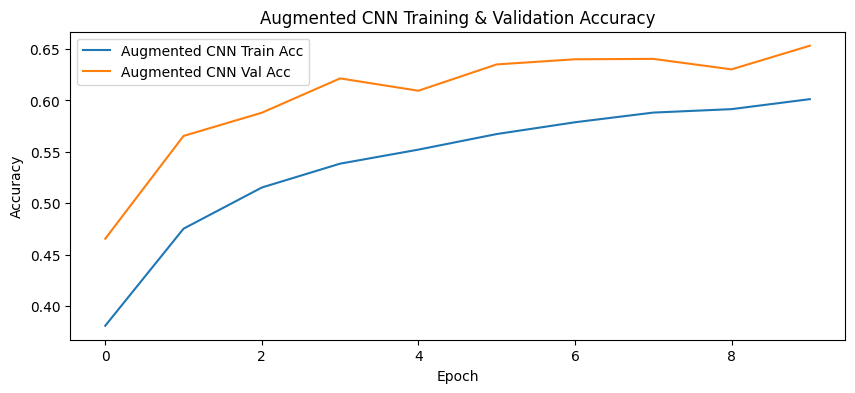

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(aug_history.history['accuracy'], label='Augmented CNN Train Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmented CNN Training & Validation Accuracy")
plt.legend()
plt.show()

## Final Comparison Table

In [ ]:
comparison= pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (V2 - More Layers, 20 Epochs, EarlyStopping)",
        "CNN (V2 - More Filters, 20 Epochs, EarlyStopping)",
        "CNN (Augmented Data, 10 Epochs)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_test_acc_v2,
        cnn_test_acc_v2,
        aug_cnn_test_acc
    ],
    "Epochs Trained": [
        10,
        10,
        len(ann_history_v2.history['accuracy']),
        len(cnn_history_v2.history['accuracy']),
        len(aug_history.history['accuracy'])
    ],
    "Strategy": [
        "Basic ANN",
        "Basic CNN",
        "More Layers + EarlyStopping",
        "More Filters + EarlyStopping",
        "Data Augmentation"
    ]
})

display(comparison)

,Model,Test Accuracy,Epochs Trained,Strategy
0,ANN (Original),0.4205,10,Basic ANN
1,CNN (Original),0.6885,10,Basic CNN
2,"ANN (V2 - More Layers, 20 Epochs, EarlyStopping)",0.4675,12,More Layers + EarlyStopping
3,"CNN (V2 - More Filters, 20 Epochs, EarlyStopping)",0.6731,7,More Filters + EarlyStopping
4,"CNN (Augmented Data, 10 Epochs)",0.6162,10,Data Augmentation


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    Input(shape=(32,32,3)), # Added Input layer explicitly
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Training Augmented CNN Model...")
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Training Augmented CNN Model...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 0.3807 - loss: 1.7067 - val_accuracy: 0.4654 - val_loss: 1.5148
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 53ms/step - accuracy: 0.4752 - loss: 1.4643 - val_accuracy: 0.5654 - val_loss: 1.2205
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.5152 - loss: 1.3628 - val_accuracy: 0.5880 - val_loss: 1.1837
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5384 - loss: 1.3071 - val_accuracy: 0.6214 - val_loss: 1.0983
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.5521 - loss: 1.2681 - val_accuracy: 0.6094 - val_loss: 1.1030
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.5672 - loss: 1.2274 - val_accuracy: 0.6350 - val_loss: 1.0307
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 49ms/step - accuracy: 0.5787 - loss: 1.2022 - val_accuracy: 0.6400 - val_loss: 1.0074
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68

/tmp/ipykernel_2501/721877448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=comparison_enhanced, palette='viridis')


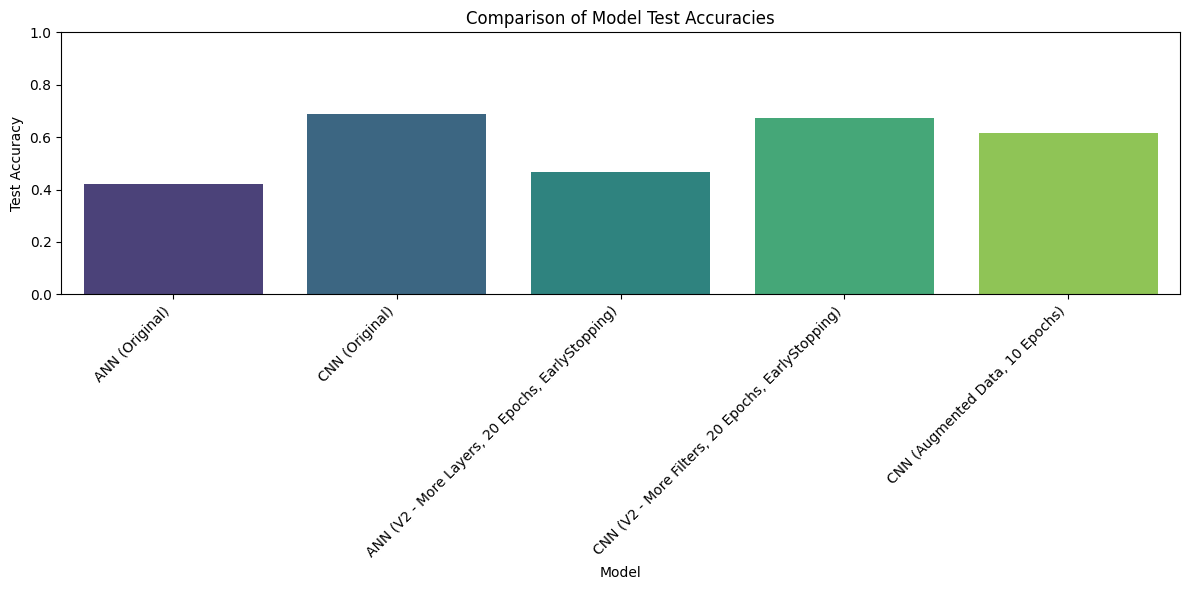

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Test Accuracy', data=comparison, palette='viridis')
plt.ylim(0, 1) # Set y-axis limit for accuracy
plt.title('Comparison of Model Test Accuracies')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Performance Comparison: 10 vs 20 Epochs

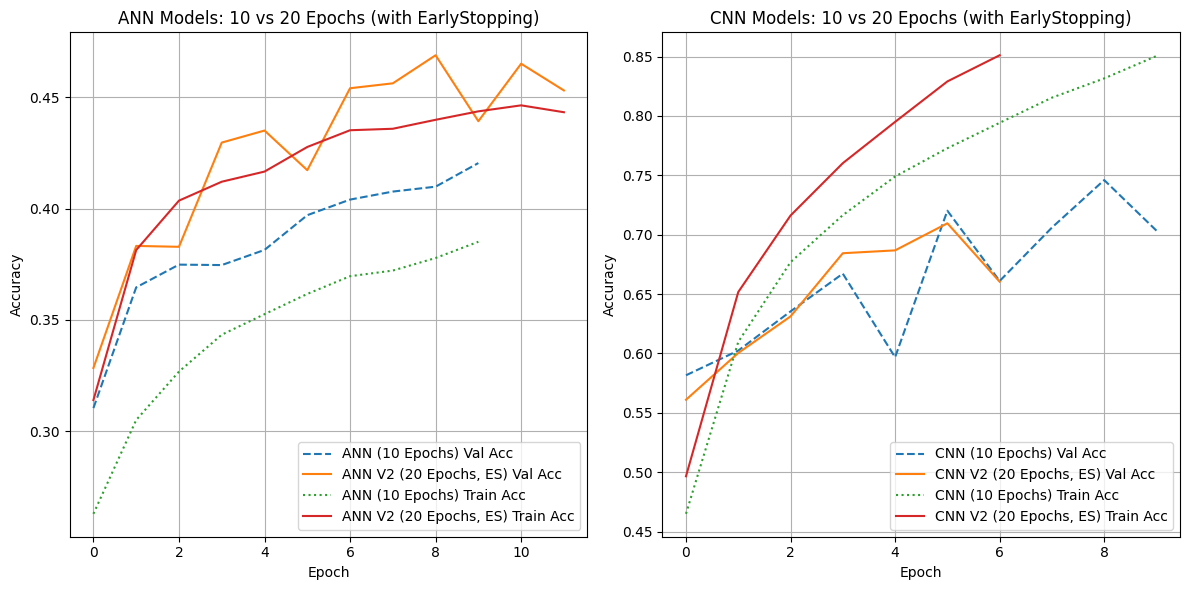

In [ ]:
plt.figure(figsize=(12, 6))

# ANN Comparison
plt.subplot(1, 2, 1)
plt.plot(ann_history.history['val_accuracy'], label='ANN (10 Epochs) Val Acc', linestyle='--')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 (20 Epochs, ES) Val Acc')
plt.plot(ann_history.history['accuracy'], label='ANN (10 Epochs) Train Acc', linestyle=':')
plt.plot(ann_history_v2.history['accuracy'], label='ANN V2 (20 Epochs, ES) Train Acc', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Models: 10 vs 20 Epochs (with EarlyStopping)")
plt.legend()
plt.grid(True)

# CNN Comparison
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['val_accuracy'], label='CNN (10 Epochs) Val Acc', linestyle='--')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 (20 Epochs, ES) Val Acc')
plt.plot(cnn_history.history['accuracy'], label='CNN (10 Epochs) Train Acc', linestyle=':')
plt.plot(cnn_history_v2.history['accuracy'], label='CNN V2 (20 Epochs, ES) Train Acc', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Models: 10 vs 20 Epochs (with EarlyStopping)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**